In [13]:
from typing import List, Literal
import matplotlib.pyplot as plt
import math

def scatter_dispersion_graph(x_axis: List[float], y_axis: List[float]):
    plt.scatter(x_axis, y_axis)
    plt.xlabel("X")
    plt.ylabel("Y")


def average(axis: List[float]) -> float:
    total_sum = sum([el for el in axis])
    return total_sum / len(axis) 


def deviation(points: List[tuple[float, float]], x_avg: float, y_avg: float) -> float:
    deviation = 0
    for p in points:
        deviation += (p[0] - x_avg) * (p[1] - y_avg)
    return deviation


def variance(
    x_axis: List[float], y_axis: List[float], x_avg: float, y_avg: float
) -> float:
    x = sum([math.pow(x - x_avg, 2) for x in x_axis])
    y = sum([math.pow(y - y_avg, 2) for y in y_axis])
    return math.sqrt(x * y)


def correlation(x_axis: List[float], y_axis: List[float]) -> float:
    x_avg = average(x_axis)
    y_avg = average(y_axis)

    points = list(zip(x_axis, y_axis))
    
    dev = deviation(points, x_avg, y_avg)
    var = variance(x_axis, y_axis, x_avg, y_avg)

    return dev / var


def regression(x_axis: List[float], y_axis: List[float]):
    x_avg = average(x_axis)
    y_avg = average(y_axis)

    points = list(zip(x_axis, y_axis))

    sum_dev = deviation(points, x_avg, y_avg)
    sqr_dev_x = sum_squared_deviation_x(x_axis, x_avg)
    
    b1 = sum_dev / sqr_dev_x
    b0 = y_avg - (b1 * x_avg)
    
    def unknown_function(x: float):
        return b0 + b1 * x
    
    return b0, b1, [unknown_function(xi) for xi in x_axis]


def sum_squared_deviation_x(x_axis: List[float], x_avg: float) -> float:
    return sum([math.pow(x - x_avg, 2) for x in x_axis])


def show_regression_graph(dataset: dict[Literal["x", "y"], List[float]]) -> None:
    x = dataset["x"]
    y = dataset["y"]
    
    # Correlação
    r = correlation(x, y)
    
    # Regressão
    b0, b1, y_model = regression(x, y)
    
    # Gráfico
    scatter_dispersion_graph(x, y)
    
    plt.plot(x, y_model)
    
    plt.title(f"r = {r:.4f} | β0 = {b0:.4f} | β1 = {b1:.4f}")
    
    plt.show()
    
    plt.close()


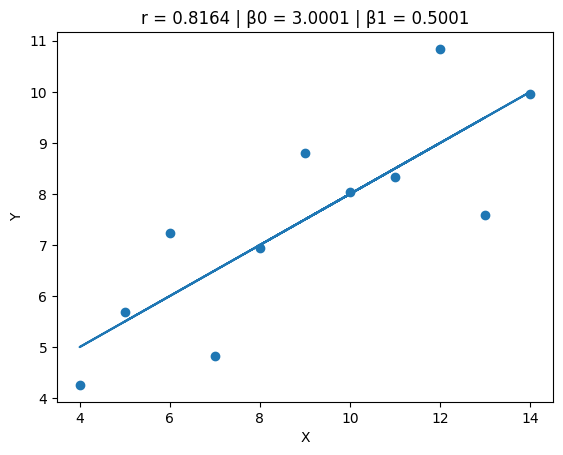

In [14]:
dataset_1 = {
    "x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5.0],
    "y": [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68],
}
show_regression_graph(dataset_1)

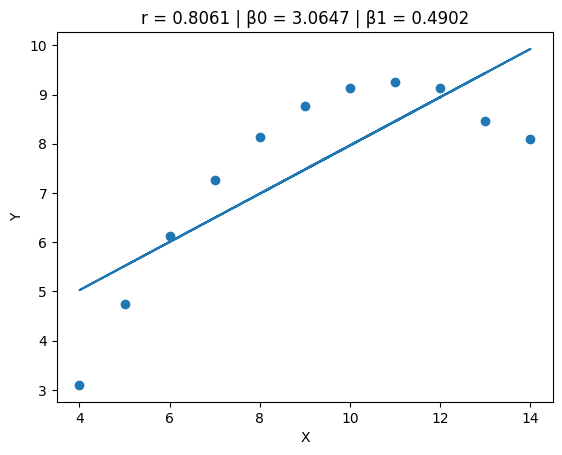

In [15]:
dataset_2 = {
    "x": [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5.0],
    "y": [9.14, 8.14, 8.47, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74],
}
show_regression_graph(dataset_2)

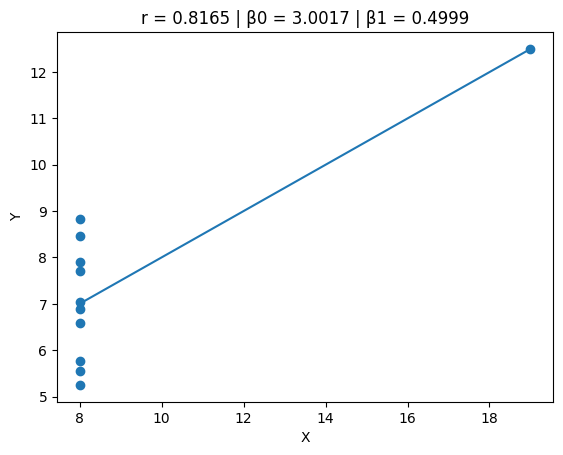

In [16]:
dataset_3 = {
    "x": [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 19.0],
    "y": [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 5.56, 7.91, 6.89, 12.50],
}
show_regression_graph(dataset_3)

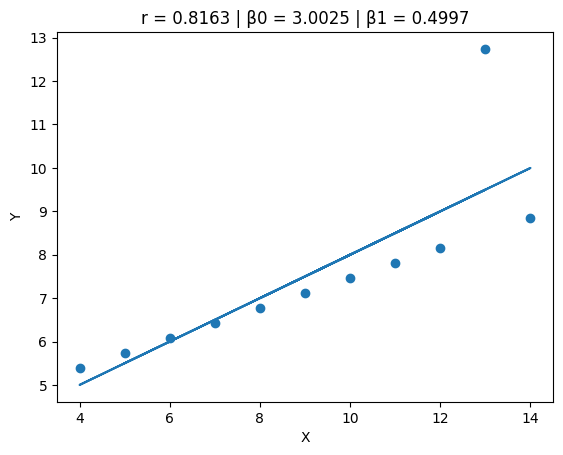

In [17]:
dataset_4 = {
    "x": [10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0],
    "y": [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73],
}
show_regression_graph(dataset_4)

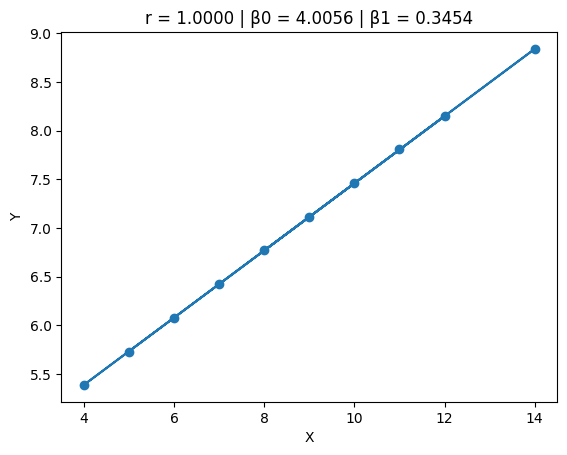

In [18]:
dataset_hypothesis = {
    "x": [10.0, 8.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0], # Sem x do outlier
    "y": [7.46, 6.77, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73], # Sem y do outlier
}
show_regression_graph(dataset_hypothesis)

# Trabalho 1: Regressão

- **Equipe**: Cristina Siewert Jansen, Marlon Sbardelatti, Sofia Sousa Lindner
- **Professora**: Andreza Sartori

## Fase 1: Análise de Correlação e Regressão Linear

#### 3. Qual dos datasets não é apropriado para regressão linear? Justifique sua resposta.

Apesar de todos os datasets demonstrarem um alto coeficiente de correlação positivo (maior que 0.8), a análise visual dos gráficos gerados permitiu a identificação de algumas inconsistências em relação ao modelo de regressão linear. A equipe aponta como não apropriados:

- **Dataset 2**: Os pontos do dataset original evidenciam um formato curvilíneo característico da regressão polinomial negativa, o que sugere uma melhor adequação a esse modelo ao invés da regressão linear.

- **Dataset 3**: Apesar do alto coeficiente de correlação, que normalmente sugeriria uma grande adequação do modelo, ao avaliar a disposição dos pontos no gráfico, entende-se que o algoritmo, por estar baseado na média das coordenadas, sofre um grande viés positivo, rementendo a uma falsa correspondência. Além disso, há apenas dois pontos cuja previsão é correspondente ao valor real.

#### 4. Ao analisar o gráfico de dispersão e o resultado da regressão linear para o dataset 4, observa-se um problema. O que deveria ser feito antes de ajustar o modelo de regressão? Justifique sua resposta.

O problema é a presença do outlier A(13, 12.74) nos dados de entrada. Ele, justamente por ter valor tão diferente da grande maioria dos dados, tem poder de distorcer valores - como a inclinação da reta.

Antes de ajustar o modelo de regressão, deve-se verificar se é possível (e necessário) realizar algum tratamento nos dados. Esse ponto que é um outlier, por exemplo, pode ser resultado de medição incorreta ou dados fora do escopo.

Para verificar se a remoção do outlier é uma decisão correta (e não somente inserção de viés no dataset), deve ser analisada sua adequação ao conjunto de dados/contexto e o impacto de sua remoção no desempenho do modelo através de métricas como o R² e o EQM.

Hipotetizou-se, através da análise da disposição dos pontos na imagem original, que a remoção do ponto outlier contribuiria para a melhora signficativa da adequação dos dados ao modelo usado. Para comprová-la, foram removidas as coordenadas do ponto nos eixos x e y e recalculou-se o modelo a partir desse dataset. Ao analisar a imagem resultante, foi possível validar a hipótese: o novo coeficiente de correlação alcançou valor máximo (1) e a imagem evidenciou que todos os dados reais passaram a corresponder às previsões do modelo.